# Dichotomous Markov Process & Mean First Passage Time

A **Dichotomous Markov Process (DMP)** is a stochastic process where an agent switches between **two discrete states**:

| State | Motion | Parameter |
|:-----:|:-------|:----------|
| **G** | Geocentric / directed drift | velocity $v$ |
| **E** | Egocentric / exploratory diffusion | coefficient $D$ |
| $\alpha$ | G $\to$ E switching rate | — |
| $\beta$ | E $\to$ G switching rate | — |

**Geometry:** $\quad x=0\;$ (start, reflecting) $\xrightarrow{\hspace{6cm}} x=L\;$ (goal, absorbing)

The **Mean First Passage Time (MFPT)** $T(x)$ is the expected time for an agent starting at $x=0$ to reach $x=L$ for the first time. A **trap** is a segment where G-motion is blocked; the agent in E can diffuse out, creating nontrivial optimal switching. Real-life applications:

| System | G state | E state | MFPT predicts |
|:-------|:--------|:--------|:--------------|
| Cellular transport | active filament transport | free diffusion | delivery time to organelle |
| Animal foraging | directed movement | exploratory search | time to find food/mate |
| Robotics | fast goal-directed motion | slow scanning | optimal reach time |
| Physics/chemistry | drift in potential | diffusion | reaction/escape time |

### Backward Kolmogorov Equations for MFPT

Instead of solving for the full distribution $P(x,t)$ via Fokker-Planck, the **Backward Kolmogorov equation** directly yields the expected time to reach a goal from any starting $(x, \text{state})$. Plugging in G-state dynamics ($dx = v\,dt$ → first derivative) and E-state dynamics ($dx \sim \mathcal{N}(0,2D\,dt)$ → second derivative):

$$\boxed{\begin{cases} v\,\dfrac{dT_G}{dx} + \alpha\,(T_E - T_G) = -1 \\[8pt] D\,\dfrac{d^2 T_E}{dx^2} + \beta\,(T_G - T_E) = -1 \end{cases}}$$

| Term | Meaning |
|:-----|:--------|
| $v\,dT_G/dx$ | deterministic drift toward $L$ |
| $D\,d^2T_E/dx^2$ | random diffusive motion |
| $\alpha(T_E - T_G)$ | stochastic switch G $\to$ E |
| $\beta(T_G - T_E)$ | stochastic switch E $\to$ G |
| $-1$ | time cost of each infinitesimal step (Bellman recursion) |

**Boundary conditions:**
$$\left.\frac{dT_G}{dx}\right|_{x=0} = 0,\quad \left.\frac{dT_E}{dx}\right|_{x=0} = 0 \qquad\text{(reflecting at start)}$$
$$T_G(L) = 0,\quad T_E(L) = 0 \qquad\qquad\qquad\quad\,\text{(absorbing at goal)}$$

**Why not Fokker-Planck?** Fokker-Planck solves $\partial_t P_G = -v\,\partial_x P_G - \alpha P_G + \beta P_E$ and $\partial_t P_E = D\,\partial_x^2 P_E + \alpha P_G - \beta P_E$ in both space and time, then integrates — much costlier. The backward equation collapses this to **two coupled ODEs in space only**.

### Finite Difference Discretisation

Divide $[0,L]$ into $N$ equal intervals, $\Delta x = L/N$, nodes $x_i = i\,\Delta x$. Replace derivatives:

$$\frac{dT_G}{dx}\bigg|_i \approx \frac{T_G^{i+1} - T_G^{i}}{\Delta x}, \qquad \frac{d^2 T_E}{dx^2}\bigg|_i \approx \frac{T_E^{i+1} - 2T_E^i + T_E^{i-1}}{(\Delta x)^2}$$

At each interior node:
$$\text{G: }\quad v\,\frac{T_G^{i+1}-T_G^{i}}{\Delta x} + \alpha\,(T_E^i - T_G^i) = -1$$
$$\text{E: }\quad D\,\frac{T_E^{i+1}-2T_E^i+T_E^{i-1}}{(\Delta x)^2} + \beta\,(T_G^i - T_E^i) = -1$$

Stacking all unknowns $\mathbf{T} = [T_G^0,\ldots,T_G^N,\;T_E^0,\ldots,T_E^N]^\top$ gives a sparse linear system $A\,\mathbf{T} = \mathbf{b}$.

| Boundary | G-state | E-state |
|:---------|:--------|:--------|
| $x=0$ (reflecting) | $T_G^0 = T_G^1$ (zero-flux) | $T_E^0 = T_E^1$ |
| $x=L$ (absorbing) | $T_G^N = 0$ | $T_E^N = 0$ |

### Parameters
We fix the physical parameters of the problem: the domain length $L$, the drift speed $v$ in state G, the diffusion coefficient $D$ in state E, and the number of spatial grid points $N$. The grid spacing $\Delta x = L/N$ controls numerical accuracy — larger $N$ gives a finer discretisation and more accurate MFPT. We then define a logarithmically spaced grid of switching rates $\alpha$ and $\beta$ over roughly three decades, which is where interesting optimal switching behaviour occurs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

L = 100       # goal position
v = 1.0       # drift speed in G
D = 0.5       # diffusion coefficient in E
N = 200       # number of spatial points
dx = L / N

alpha_vals = np.logspace(-2, 1.7, 30)  # 0.01 -> ~50
beta_vals  = np.logspace(-2, 1.7, 30)  # 0.01 -> ~50

### Building and Solving the Linear System

The function `solve_mfpt(α, β)` assembles the matrix $A$ and right-hand side $\mathbf{b}$ that encode the discretised backward equations, then solves $A\mathbf{T}=\mathbf{b}$ directly.

The state vector is laid out as $\mathbf{T} = [T_G^0,\ldots,T_G^N,\;T_E^0,\ldots,T_E^N]^\top$, so index $g = i$ refers to node $i$ in G, and index $e = i + (N+1)$ refers to node $i$ in E. Three cases fill the matrix:

| Case | Row(s) | What is encoded |
|:-----|:-------|:----------------|
| $i = N$ | both $g,e$ | Absorbing boundary: $T_G^N = T_E^N = 0$ |
| $i = 0$ | G-row | Upwind drift: $v(T_G^1 - T_G^0)/\Delta x + \alpha(T_E^0-T_G^0) = -1$ |
| $i = 0$ | E-row | Reflecting (zero-flux): $T_E^0 = T_E^1$ |
| $0 < i < N$ | G-row | Upwind drift + switching |
| $0 < i < N$ | E-row | Central difference diffusion + switching |

**Upwind differencing** (using $T_G^{i+1} - T_G^i$ rather than the centred form) is used for the drift term because the agent always moves in the $+x$ direction; it avoids spurious oscillations that centred schemes produce for convection-dominated problems. The return value is $T_G^0$ — the MFPT at the start position $x=0$ in state G.

In [2]:
def solve_mfpt(alpha, beta):
    x = np.linspace(0, L, N+1)
    T_size = 2*(N+1)
    
    A = np.zeros((T_size, T_size))
    b = np.zeros(T_size)
    
    for i in range(N+1):
        g = i
        e = i + N + 1
        
        if i == N:
            # Absorbing at goal
            A[g, g] = 1
            A[e, e] = 1
            b[g] = 0
            b[e] = 0
        elif i == 0:
            # Reflecting at start for E (diffusion)
            # For G, standard backward eq
            A[g, g] = -v/dx - alpha
            A[g, g+1] = v/dx
            A[g, e] = alpha
            b[g] = -1
            
            A[e, e] = 1
            A[e, e+1] = -1
            b[e] = 0
        else:
            # Interior points
            # G mode (drift)
            A[g, g] = -v/dx - alpha
            A[g, g+1] = v/dx
            A[g, e] = alpha
            b[g] = -1
            
            # E mode (diffusion)
            A[e, e-1] = D/dx**2
            A[e, e]   = -2*D/dx**2 - beta
            A[e, e+1] = D/dx**2
            A[e, g]   = beta
            b[e] = -1
    
    T = np.linalg.solve(A, b)
    T_G = T[:N+1]
    T_E = T[N+1:]
    
    return T_G[0]  # MFPT starting at x=0, state G

### Parameter Sweep over $(\alpha, \beta)$

We evaluate $T_G(0;\,\alpha,\beta)$ on the full $30\times 30$ logarithmic grid, storing results in the matrix $\texttt{MFPT}[i,j]$. This is a brute-force landscape exploration: for each pair $(\alpha_i,\beta_j)$ we assemble and solve a fresh $2(N+1)\times 2(N+1)$ linear system. The total cost is $30^2 = 900$ solves, each $O(N^2)$ for a dense system — feasible because $N=200$ is modest. The minimum of this landscape, found with `np.argmin`, identifies the **optimal switching rates** $(\alpha^*,\beta^*)$ that minimise the expected travel time from start to goal.

In [3]:
MFPT = np.zeros((len(alpha_vals), len(beta_vals)))

for i, alpha in enumerate(alpha_vals):
    for j, beta in enumerate(beta_vals):
        MFPT[i,j] = solve_mfpt(alpha, beta)
        print(f"α={alpha:.3f}, β={beta:.3f}, MFPT={MFPT[i,j]:.3f}")

min_idx   = np.unravel_index(np.argmin(MFPT), MFPT.shape)
alpha_opt = alpha_vals[min_idx[0]]
beta_opt  = beta_vals[min_idx[1]]
mfpt_min  = MFPT[min_idx]

print("\n===== OPTIMAL SWITCHING =====")
print(f"Minimum MFPT ≈ {mfpt_min:.3f} at α ≈ {alpha_opt:.3f}, β ≈ {beta_opt:.3f}")

α=0.010, β=0.010, MFPT=192.341
α=0.010, β=0.013, MFPT=169.603
α=0.010, β=0.018, MFPT=152.373
α=0.010, β=0.024, MFPT=139.353
α=0.010, β=0.032, MFPT=129.533
α=0.010, β=0.043, MFPT=122.141
α=0.010, β=0.058, MFPT=116.585
α=0.010, β=0.078, MFPT=112.414
α=0.010, β=0.105, MFPT=109.286
α=0.010, β=0.141, MFPT=106.942
α=0.010, β=0.189, MFPT=105.187
α=0.010, β=0.253, MFPT=103.874
α=0.010, β=0.340, MFPT=102.892
α=0.010, β=0.456, MFPT=102.159
α=0.010, β=0.611, MFPT=101.611
α=0.010, β=0.820, MFPT=101.201
α=0.010, β=1.100, MFPT=100.895
α=0.010, β=1.476, MFPT=100.667
α=0.010, β=1.979, MFPT=100.497
α=0.010, β=2.655, MFPT=100.370
α=0.010, β=3.562, MFPT=100.275
α=0.010, β=4.779, MFPT=100.205
α=0.010, β=6.411, MFPT=100.152
α=0.010, β=8.600, MFPT=100.113
α=0.010, β=11.536, MFPT=100.083
α=0.010, β=15.476, MFPT=100.061
α=0.010, β=20.761, MFPT=100.045
α=0.010, β=27.850, MFPT=100.033
α=0.010, β=37.361, MFPT=100.024
α=0.010, β=50.119, MFPT=100.017
α=0.013, β=0.010, MFPT=223.736
α=0.013, β=0.013, MFPT=193.293
α=

### 2-D Heatmap of $T_G(0;\,\alpha,\beta)$

`contourf` renders the MFPT landscape on log–log axes: each filled contour is an iso-MFPT curve. Both axes are logarithmic because the interesting dynamics span several decades. The red dot marks $(\beta^*,\alpha^*)$, the global minimiser found above. Dark regions (low MFPT) correspond to switching rates that keep the agent in the faster state for the right amount of time — too slow a switch wastes time diffusing; too fast a switch prevents sustained drift.

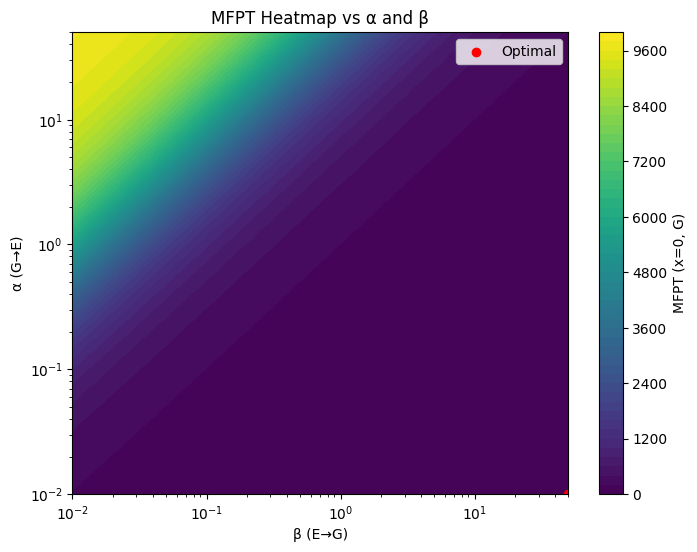

In [4]:
plt.figure(figsize=(8,6))
plt.contourf(beta_vals, alpha_vals, MFPT, levels=50, cmap='viridis')
plt.colorbar(label='MFPT (x=0, G)')
plt.scatter(beta_opt, alpha_opt, color='red', label='Optimal')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('β (E→G)')
plt.ylabel('α (G→E)')
plt.title('MFPT Heatmap vs α and β')
plt.legend()
plt.show()

### 3-D Surface of $T_G(0;\,\alpha,\beta)$

`np.meshgrid` with `indexing='ij'` ensures $\alpha$ varies along rows and $\beta$ along columns, consistent with the storage order of `MFPT`. The surface is plotted against $\log_{10}\beta$ (x-axis) and $\log_{10}\alpha$ (y-axis) so the wide dynamic range is visible. `view_init(elev=30, azim=45)` sets the camera angle to show both the valley structure and the optimal point simultaneously. The red scatter point sits at the bottom of the valley — the unique minimiser of MFPT over the $(\alpha,\beta)$ landscape.

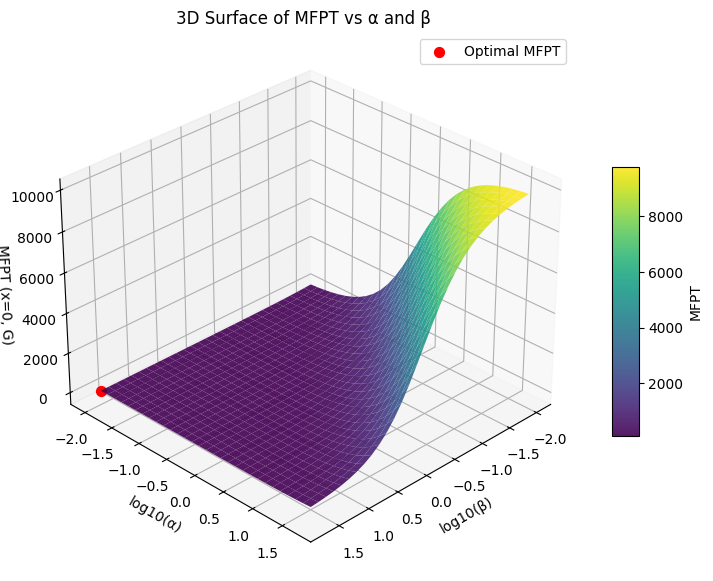

In [5]:
from mpl_toolkits.mplot3d import Axes3D

Alpha_grid, Beta_grid = np.meshgrid(alpha_vals, beta_vals, indexing='ij')

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(np.log10(Beta_grid), np.log10(Alpha_grid), MFPT,
                       cmap='viridis', edgecolor='none', alpha=0.9)

ax.scatter(np.log10(beta_opt), np.log10(alpha_opt), mfpt_min,
           color='red', s=50, label='Optimal MFPT')

ax.set_xlabel('log10(β)')
ax.set_ylabel('log10(α)')
ax.set_zlabel('MFPT (x=0, G)')
ax.set_title('3D Surface of MFPT vs α and β')
ax.view_init(elev=30, azim=45)
ax.legend()
fig.colorbar(surf, shrink=0.5, aspect=10, label='MFPT')
plt.show()

### Reading the Solution

$T_G(x)$ — expected time to reach $L$ starting at $x$ in **G state** $\;\cdot\;$ $T_E(x)$ — same but in **E state**.

Typical behaviour: $T_G(x) < T_E(x)$ near the start when drift dominates diffusion; $T_E$ is smoother because diffusion spreads probability. Switching rates $\alpha,\beta$ control how rapidly the agent alternates — **the minimum MFPT over $(\alpha,\beta)$ is the optimal switching strategy**. The heatmap and 3-D surface of MFPT vs $\log_{10}\alpha$, $\log_{10}\beta$ show a clear minimum (red dot) — the pair $(\alpha^*,\beta^*)$ that minimises expected travel time from $x=0$ in state G.

# Summary of 1D DMP MFPT Analysis

Here’s what we did step by step:

1. **1D World Setup**  
   - Start at \(x=0\) (reflecting boundary)  
   - Goal at \(x=L\) (absorbing boundary)  
   - No obstacles in this basic case  

2. **Two Navigation Modes**  
   - **G state (Geo)** → drift toward goal with velocity \(v\)  
   - **E state (Ego)** → random diffusion with coefficient \(D\)  
   - **Switching rates:** α = G → E, β = E → G  

3. **Backward Kolmogorov Equation**  
   - Solve for **MFPT** as a function of α (with β fixed) or vice versa  
   - Can sweep **both α and β** together to find **optimal switching rates** that **minimize MFPT**  

4. **Interpretation**  
   - \(T_G(x)\) and \(T_E(x)\) encode the **dynamics of drift and diffusion** respectively  
   - The derivatives \(dT_G/dx\) and \(d^2T_E/dx^2\) represent **motion in each state**  
   - If you study a different motion type (e.g., **Correlated Random Walk, Lévy Flight, etc.**), you can **replace the derivatives with the corresponding dynamics**  
   - The backward equation framework will then still give **expected time to reach goal**, i.e., MFPT  

5. **Optimal Strategy**  
   - For a 1D case: starting at \(x=0\) and goal at \(x=L\),  
     the **optimal switching rates α=x, β=y** are those that **minimize the MFPT**  

6. **Key Insight**  
   - This approach **generalizes to any motion type** as long as you can write the dynamics in G and E states  
   - It provides a **quantitative way to find the best strategy** for reaching a goal under stochastic dynamics

# Analysis of MFPT Plots

We generated **three main types of plots** to understand how MFPT depends on the switching rate α:

---

## 1️⃣ Linear Scale Plot

- **X-axis:** α (switching rate G → E)  
- **Y-axis:** MFPT (mean first passage time from x=0 in G state)  

**Observation:**

- Shows how MFPT changes as α increases  
- Typically **MFPT increases for large α**, because the agent spends less time drifting toward the goal and more time diffusing randomly  
- Provides a **direct, intuitive view** of the data

---

## 2️⃣ Log-Log Plot

- **X-axis:** log(α)  
- **Y-axis:** log(MFPT)  

**Purpose:**

- To test for **power-law behavior**:  
  \[
  \text{MFPT} \sim \alpha^s
  \]  
- If the points form a roughly straight line on log-log scale → **power-law relationship** exists  

**Observation:**

- At high α, the log-log plot often shows a **linear trend**, indicating MFPT increases approximately as a power of α  
- The **slope** of the line gives the **power-law exponent**  

---

## 3️⃣ Semi-Log Plot

- **X-axis:** α (linear scale)  
- **Y-axis:** log(MFPT)  

**Purpose:**

- To test for **exponential dependence**:  
  \[
  \text{MFPT} \sim e^{k\alpha}
  \]  
- If the points form a straight line on semi-log → MFPT grows exponentially with α  

**Observation:**

- Often MFPT does **not fit exponential** well in this problem  
- R² values from the fit confirm **power-law is a better descriptor** at large α than exponential

---

### 🔹 Key Takeaways from Plots

1. **Linear plot** → direct trend of MFPT vs α  
2. **Log-log plot** → identifies approximate **power-law scaling** for high α  
3. **Semi-log plot** → shows that **exponential growth is not supported**  

**Conclusion:**  

- MFPT increases with α in a **nonlinear fashion**  
- **Optimal α** occurs at **small α**, where the agent drifts efficiently toward the goal with minimal time spent diffusing  
- Log-log analysis is useful to **characterize scaling behavior** of MFPT

# MFPT vs Switching Rate (Linear Scale)

![MFPT linear plot](mfpt_linear.png)

# MFPT vs Switching Rate (Log-Log Scale)

![MFPT log-log plot](mfpt_loglog.png)

# MFPT vs Switching Rate (Semi-Log Scale)

![MFPT semi-log plot](mfpt_semilog.png)